Lets explore a data set containing. IMDb data on 1,000 popular movies, including columns like title, genre,
year, rating, duration, and more. 

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("imdb_top_1000.csv")

print(df.head(10))
print("---------------------------")
print(df.info())
print("---------------------------")


   Rank                    Title                       Genre  \
0     1  Guardians of the Galaxy     Action,Adventure,Sci-Fi   
1     2               Prometheus    Adventure,Mystery,Sci-Fi   
2     3                    Split             Horror,Thriller   
3     4                     Sing     Animation,Comedy,Family   
4     5            Suicide Squad    Action,Adventure,Fantasy   
5     6           The Great Wall    Action,Adventure,Fantasy   
6     7               La La Land          Comedy,Drama,Music   
7     8                 Mindhorn                      Comedy   
8     9       The Lost City of Z  Action,Adventure,Biography   
9    10               Passengers     Adventure,Drama,Romance   

                                         Description              Director  \
0  A group of intergalactic criminals are forced ...            James Gunn   
1  Following clues to the origin of mankind, a te...          Ridley Scott   
2  Three girls are kidnapped by a man with a diag...    M. Ni

This code below summarizes each category for count, mean, std, min, 25th percentile, 50th percentile, 75th percentile, and the max of each column in the csv file.

In [3]:
##4
summary = df.describe()
print(summary)

              Rank         Year  Runtime (Minutes)       Rating         Votes  \
count  1000.000000  1000.000000        1000.000000  1000.000000  1.000000e+03   
mean    500.500000  2012.783000         113.172000     6.723200  1.698083e+05   
std     288.819436     3.205962          18.810908     0.945429  1.887626e+05   
min       1.000000  2006.000000          66.000000     1.900000  6.100000e+01   
25%     250.750000  2010.000000         100.000000     6.200000  3.630900e+04   
50%     500.500000  2014.000000         111.000000     6.800000  1.107990e+05   
75%     750.250000  2016.000000         123.000000     7.400000  2.399098e+05   
max    1000.000000  2016.000000         191.000000     9.000000  1.791916e+06   

       Revenue (Millions)   Metascore  
count          872.000000  936.000000  
mean            82.956376   58.985043  
std            103.253540   17.194757  
min              0.000000   11.000000  
25%             13.270000   47.000000  
50%             47.985000   59

summarizes: rank, year, runtime, rating, votes, revenue, and metascore

array([[<Axes: title={'center': 'Rank'}>,
        <Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Runtime (Minutes)'}>],
       [<Axes: title={'center': 'Rating'}>,
        <Axes: title={'center': 'Votes'}>,
        <Axes: title={'center': 'Revenue (Millions)'}>],
       [<Axes: title={'center': 'Metascore'}>, <Axes: >, <Axes: >]],
      dtype=object)

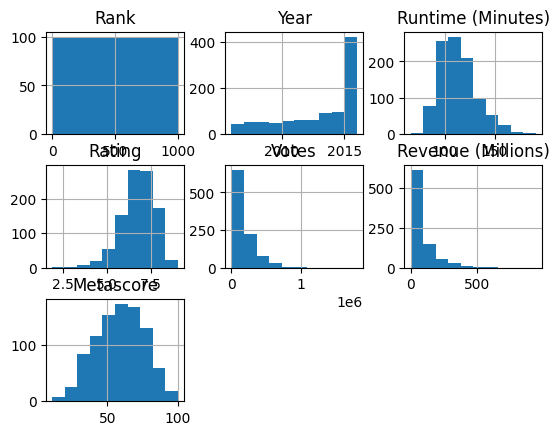

In [4]:
df.hist(bins=10)

rank graph not super helpful; have to check the columns
runtimes are clustered yes. STD is low. 

In [5]:
#variance
hello = df['Rating'].var()
print(hello)

0.8938355955955956


In [6]:
hi = df['Rating'].sort_values()
print(hi.tail(10))

991    8.5
99     8.5
124    8.5
133    8.5
96     8.6
36     8.6
249    8.6
117    8.8
80     8.8
54     9.0
Name: Rating, dtype: float64


In [11]:
count = 0
for i in df['Rating']:
    if i > 8.5:
        print(i)
        count += 1
print(f'there are {count} numbers that are greater than 8.5')

8.6
9.0
8.8
8.6
8.8
8.6
there are 6 numbers that are greater than 8.5


In [52]:
darshan = df['Rating'].corr(df['Runtime (Minutes)'])
print(darshan)

0.3922142455250514


In [1]:
# Filtering using multiple conditions: filter the DataFrame to show only movies with Rating > 8.0
# AND Runtime < 100.

filtered_df = df[(df['Rating'] > 8.0) & (df["Runtime (Minutes)"] < 100)]
print(filtered_df)

# not sure exaclt ywhy it'd be important to investigate these ones. 

NameError: name 'df' is not defined

there are a couple of outliers for sure... most of the ratings are centered around a 7- kinda says something about how humans are really comfortable with rating things a "7" because its the least critical but certainly not an extravagent number.

{'whiskers': [<matplotlib.lines.Line2D at 0x1229657f0>,
 'caps': [<matplotlib.lines.Line2D at 0x122965a90>,
 'boxes': [<matplotlib.lines.Line2D at 0x1229656a0>],
 'medians': [<matplotlib.lines.Line2D at 0x122965d30>],
 'fliers': [<matplotlib.lines.Line2D at 0x122965e80>],
 'means': []}

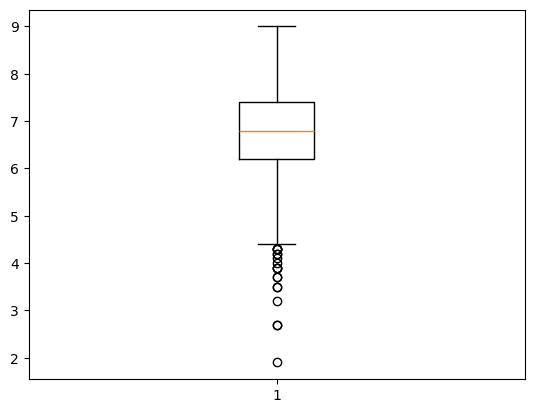

In [30]:
plt.boxplot(df["Rating"])

Grouping the DataFrame by
"Genre" and calculating the average IMDB_Rating per genre. 
rating?

In [2]:
a = df.groupby('Genre')
print(a)
# how does one do this? I am so confused ....

NameError: name 'df' is not defined

Lets drop all rows that don't have any info

In [54]:
df.isnull().sum()

Rank                    0
Title                   0
Genre                   0
Description             0
Director                0
Actors                  0
Year                    0
Runtime (Minutes)       0
Rating                  0
Votes                   0
Revenue (Millions)    128
Metascore              64
dtype: int64

In [93]:
df_cleaned = df.dropna()
print(df_cleaned)

     Rank                     Title                     Genre  \
0       1   Guardians of the Galaxy   Action,Adventure,Sci-Fi   
1       2                Prometheus  Adventure,Mystery,Sci-Fi   
2       3                     Split           Horror,Thriller   
3       4                      Sing   Animation,Comedy,Family   
4       5             Suicide Squad  Action,Adventure,Fantasy   
..    ...                       ...                       ...   
993   994  Resident Evil: Afterlife   Action,Adventure,Horror   
994   995                 Project X                    Comedy   
996   997           Hostel: Part II                    Horror   
997   998    Step Up 2: The Streets       Drama,Music,Romance   
999  1000                Nine Lives     Comedy,Family,Fantasy   

                                           Description              Director  \
0    A group of intergalactic criminals are forced ...            James Gunn   
1    Following clues to the origin of mankind, a te...     

Grouping by year: Let’s examine how movie ratings have changed over time. Group the data by
"Released_Year" and calculate average "IMDB_Rating" per year. Plot a line chart of average
rating by year. What trend do you see?

18) Grouping by year: Let’s examine how movie ratings have changed over time. Group the data by
"Released_Year" and calculate average "IMDB_Rating" per year. Plot a line chart of average
rating by year. What trend do you see?


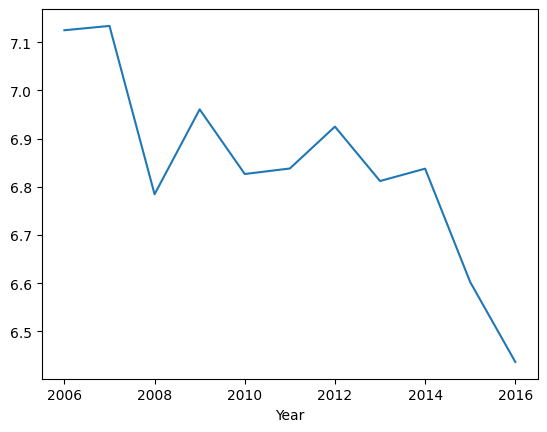

In [78]:
a = df.groupby('Year')['Rating'].mean().plot()
# average rating generally decreases over time... what could that mean?

The three most common directors are below.


In [84]:
df['Director'].value_counts().head(3)

Director
Ridley Scott          8
David Yates           6
M. Night Shyamalan    6
Name: count, dtype: int64

These are the movies that are particularly long, ie they have a runtime > 2 std over the mean

In [103]:
print(int(df_cleaned['Runtime (Minutes)'].mean()))
print(int(df_cleaned['Runtime (Minutes)'].std()))

long = df[(df['Runtime (Minutes)']) > 150]
print(long)

114
18
     Rank                                              Title  \
26     27                            Bahubali: The Beginning   
36     37                                       Interstellar   
54     55                                    The Dark Knight   
55     56                                            Silence   
60     61                 Batman v Superman: Dawn of Justice   
75     76           Pirates of the Caribbean: At World's End   
77     78                               Inglourious Basterds   
78     79         Pirates of the Caribbean: Dead Man's Chest   
82     83                            The Wolf of Wall Street   
87     88                                             Avatar   
88     89                                  The Hateful Eight   
90     91                                          Prisoners   
99    100                                       The Departed   
117   118                                             Dangal   
124   125                        

lets find out which genre had the highest amount of votes.

In [117]:
maxvotes = df_cleaned.loc[df_cleaned.groupby('Genre')['Votes'].idxmax()]
print(maxvotes.sort_values('Votes',ascending=False)[['Genre','Title','Votes']])

                       Genre                  Title    Votes
54        Action,Crime,Drama        The Dark Knight  1791916
80   Action,Adventure,Sci-Fi              Inception  1583625
124          Action,Thriller  The Dark Knight Rises  1222645
36    Adventure,Drama,Sci-Fi           Interstellar  1047747
76             Action,Sci-Fi           The Avengers  1045588
..                       ...                    ...      ...
793   Animation,Comedy,Drama    Ma vie de Courgette     4370
643        Drama,History,War                 Frantz     4304
110   Action,Horror,Thriller   The Belko Experiment     3712
949                Adventure                  Kicks     2417
616                   Sci-Fi   2307: Winter's Dream      277

[189 rows x 3 columns]


i'm gonna group the data by director and use the aggergate method to calcuate mean, median and std of imdb rating and then plot it.

<Axes: >

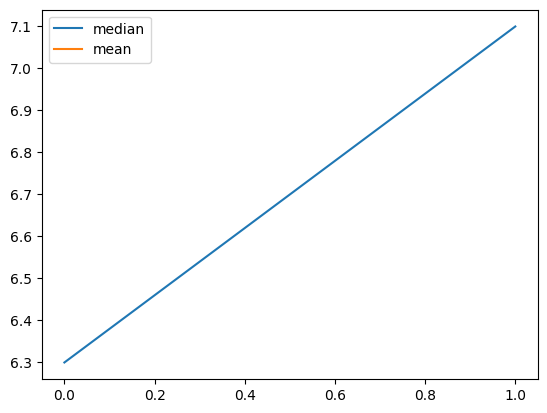

In [22]:
df.groupby('Director')['Rating'].agg(['median', 'mean']).agg(pd.Series.mode).plot()

Create a new column called "Movie_Length" using pd.cut(). Categorize movies into "Short" (0–90), "Standard" (90–150), and "Epic" (150–500) using the bins and labels parameters.

The below code Sorts the DataFrame by Rating in descending order and "No_of_Votes" in descending
order simultaneously using .sort_values(). 

In [6]:
df.sort_values(by=['Rating', 'Votes'], ascending=[False, False])

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
54,55,The Dark Knight,"Action,Crime,Drama",When the menace known as the Joker wreaks havo...,Christopher Nolan,"Christian Bale, Heath Ledger, Aaron Eckhart,Mi...",2008,152,9.0,1791916,533.32,82.0
80,81,Inception,"Action,Adventure,Sci-Fi","A thief, who steals corporate secrets through ...",Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ellen...",2010,148,8.8,1583625,292.57,74.0
117,118,Dangal,"Action,Biography,Drama",Former wrestler Mahavir Singh Phogat and his t...,Nitesh Tiwari,"Aamir Khan, Sakshi Tanwar, Fatima Sana Shaikh,...",2016,161,8.8,48969,11.15,NaN
36,37,Interstellar,"Adventure,Drama,Sci-Fi",A team of explorers travel through a wormhole ...,Christopher Nolan,"Matthew McConaughey, Anne Hathaway, Jessica Ch...",2014,169,8.6,1047747,187.99,74.0
249,250,The Intouchables,"Biography,Comedy,Drama",After he becomes a quadriplegic from a paragli...,Olivier Nakache,"François Cluzet, Omar Sy, Anne Le Ny, Audrey F...",2011,112,8.6,557965,13.18,57.0
...,...,...,...,...,...,...,...,...,...,...,...,...
890,891,The Intent,"Crime,Drama",Gunz (Dylan Duffus) is thrust into a world of ...,Femi Oyeniran,"Dylan Duffus, Scorcher,Shone Romulus, Jade Asha",2016,104,3.5,202,NaN,59.0
647,648,Tall Men,"Fantasy,Horror,Thriller",A challenged man is stalked by tall phantoms i...,Jonathan Holbrook,"Dan Crisafulli, Kay Whitney, Richard Garcia, P...",2016,133,3.2,173,NaN,57.0
871,872,Dragonball Evolution,"Action,Adventure,Fantasy",The young warrior Son Goku sets out on a quest...,James Wong,"Justin Chatwin, James Marsters, Yun-Fat Chow, ...",2009,85,2.7,59512,9.35,45.0
42,43,Don't Fuck in the Woods,Horror,A group of friends are going on a camping trip...,Shawn Burkett,"Brittany Blanton, Ayse Howard, Roman Jossart,N...",2016,73,2.7,496,NaN,NaN


Creating a new column called "Movie_Length" using pd.cut(). Categorizing movies into "Short"
(0–90), "Standard" (90–150), and "Epic" (150–500) using the bins and labels parameters.

In [12]:
bins = [0, 90, 150, 500]
lab = ['short', 'standard', 'epic']

df['Movie_Length'] = pd.cut(df['Runtime (Minutes)'], bins=bins, labels=lab, include_lowest=True)
print(df['Movie_Length'])

0      standard
1      standard
2      standard
3      standard
4      standard
         ...   
995    standard
996    standard
997    standard
998    standard
999       short
Name: Movie_Length, Length: 1000, dtype: category
Categories (3, object): ['short' < 'standard' < 'epic']


Creating a list of three genres of my choice (in this case, action, comedy, and drama). Using the .isin() method to filter the DataFrame
so it only includes movies that match those specific genres.

In [14]:
genres = ['Action', 'Comedy', 'Drama']

filtered_df = df[df['Genre'].isin(genres)]

print(filtered_df.head())
print(filtered_df.shape)

    Rank                  Title   Genre  \
7      8               Mindhorn  Comedy   
21    22  Manchester by the Sea   Drama   
25    26        Paris pieds nus  Comedy   
28    29               Bad Moms  Comedy   
30    31               Why Him?  Comedy   

                                          Description          Director  \
7   A has-been actor best known for playing the ti...        Sean Foley   
21  A depressed uncle is asked to take care of his...  Kenneth Lonergan   
25  Fiona visits Paris for the first time to assis...    Dominique Abel   
28  When three overworked and under-appreciated mo...         Jon Lucas   
30  A holiday gathering threatens to go off the ra...      John Hamburg   

                                               Actors  Year  \
7   Essie Davis, Andrea Riseborough, Julian Barrat...  2016   
21  Casey Affleck, Michelle Williams, Kyle Chandle...  2016   
25  Fiona Gordon, Dominique Abel,Emmanuelle Riva, ...  2016   
28  Mila Kunis, Kathryn Hahn, Kristen 

Using groupby("Year")["IMDB_Rating"].idxmax() to find the index of the
highest-rated movie for every year. 

In [16]:
df.groupby('Year')['Rating'].idxmax()

Year
2006     64
2007    991
2008     54
2009    430
2010     80
2011    249
2012    124
2013     82
2014     36
2015     26
2016    117
Name: Rating, dtype: int64

Using the query() method to filter the DataFrame for movies where "Rating" is greater
than 8.0 and "Votes" is greater than 100,000.

In [21]:
df.query("Rating > 8.0 and Votes > 100000")

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore,Movie_Length
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0,standard
6,7,La La Land,"Comedy,Drama,Music",A jazz pianist falls for an aspiring actress i...,Damien Chazelle,"Ryan Gosling, Emma Stone, Rosemarie DeWitt, J....",2016,128,8.3,258682,151.06,93.0,standard
16,17,Hacksaw Ridge,"Biography,Drama,History","WWII American Army Medic Desmond T. Doss, who ...",Mel Gibson,"Andrew Garfield, Sam Worthington, Luke Bracey,...",2016,139,8.2,211760,67.12,71.0,standard
18,19,Lion,"Biography,Drama",A five-year-old Indian boy gets lost on the st...,Garth Davis,"Dev Patel, Nicole Kidman, Rooney Mara, Sunny P...",2016,118,8.1,102061,51.69,69.0,standard
36,37,Interstellar,"Adventure,Drama,Sci-Fi",A team of explorers travel through a wormhole ...,Christopher Nolan,"Matthew McConaughey, Anne Hathaway, Jessica Ch...",2014,169,8.6,1047747,187.99,74.0,epic
50,51,Star Wars: Episode VII - The Force Awakens,"Action,Adventure,Fantasy",Three decades after the defeat of the Galactic...,J.J. Abrams,"Daisy Ridley, John Boyega, Oscar Isaac, Domhna...",2015,136,8.1,661608,936.63,81.0,standard
54,55,The Dark Knight,"Action,Crime,Drama",When the menace known as the Joker wreaks havo...,Christopher Nolan,"Christian Bale, Heath Ledger, Aaron Eckhart,Mi...",2008,152,9.0,1791916,533.32,82.0,epic
64,65,The Prestige,"Drama,Mystery,Sci-Fi",Two stage magicians engage in competitive one-...,Christopher Nolan,"Christian Bale, Hugh Jackman, Scarlett Johanss...",2006,130,8.5,913152,53.08,66.0,standard
67,68,Mad Max: Fury Road,"Action,Adventure,Sci-Fi",A woman rebels against a tyrannical ruler in p...,George Miller,"Tom Hardy, Charlize Theron, Nicholas Hoult, Zo...",2015,120,8.1,632842,153.63,90.0,standard
74,75,Zootopia,"Animation,Adventure,Comedy","In a city of anthropomorphic animals, a rookie...",Byron Howard,"Ginnifer Goodwin, Jason Bateman, Idris Elba, J...",2016,108,8.1,296853,341.26,78.0,standard
